# **Лабораторная работа 3: hard-часть**

В этой части используется упрощенная ручная вейвлет-фильтрация Хаара и внешний датасет с двумя типами датчиков: акселерометром и гироскопом.

## Теоретическая справка

Вейвлет-фильтрация рассматривает сигнал на разных масштабах. В отличие от обычного сглаживания в окне, вейвлет-преобразование отделяет грубую форму сигнала от локальных быстрых изменений.

В этой работе реализован базовый вейвлет Хаара. Для соседней пары значений $x_{2k}$ и $x_{2k+1}$ считаются два коэффициента:

$$
a_k = \frac{x_{2k} + x_{2k+1}}{\sqrt{2}}, \qquad d_k = \frac{x_{2k} - x_{2k+1}}{\sqrt{2}}.
$$

$a_k$ — аппроксимация, то есть более грубое описание сигнала. $d_k$ — деталь, то есть локальная разность между соседними значениями. Если повторить эту операцию несколько раз для аппроксимаций, получится многоуровневое разложение.

Для подавления шума мелкие детальные коэффициенты уменьшаются или зануляются. В работе используется soft-thresholding:

$$
\tilde d = sign(d) \max(|d|-\lambda, 0).
$$

После этого сигнал восстанавливается обратным преобразованием. Такая реализация проще, чем полноценные семейства Daubechies или Symlet, но хорошо показывает основную идею вейвлет-фильтрации.

## Датасет

Для hard-части используется Kaggle dataset **Fitness Tracker - Accelerometer & Gyroscope Data**: https://www.kaggle.com/datasets/krishujeniya/fitness-tracker-accelerometer-and-gyroscope-data

В нем есть временные ряды двух датчиков:

- акселерометр: `Accelerometer_x`, `Accelerometer_y`, `Accelerometer_z`;
- гироскоп: `Gyroscope_x`, `Gyroscope_y`, `Gyroscope_z`.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.data_loader import isu_to_variant, load_variant_data
from src.filters import haar_wavelet_denoise
from src.hard_data_loader import KAGGLE_DATASET, ensure_fitness_tracker_dataset, load_fitness_tracker_data
from src.metrics import filtering_summary

plt.style.use("seaborn-v0_8-whitegrid")

## Вейвлет-фильтрация прибыли

Сначала применим вейвлет Хаара к данным из основной части лабораторной, чтобы сравнить результат с уже знакомым рядом прибыли.

In [10]:
variant = isu_to_variant(466761)
sales_data = load_variant_data(ROOT / "sell.csv", variant)

profit = sales_data["profit"].to_numpy(dtype=float)
wavelet_profit = haar_wavelet_denoise(profit, levels=3, threshold_mode="soft")

filtering_summary(profit, {"haar_wavelet": wavelet_profit})

,method,rmse_to_original,smoothness,smoothness_ratio
0,haar_wavelet,1.554713,0.505664,0.196959


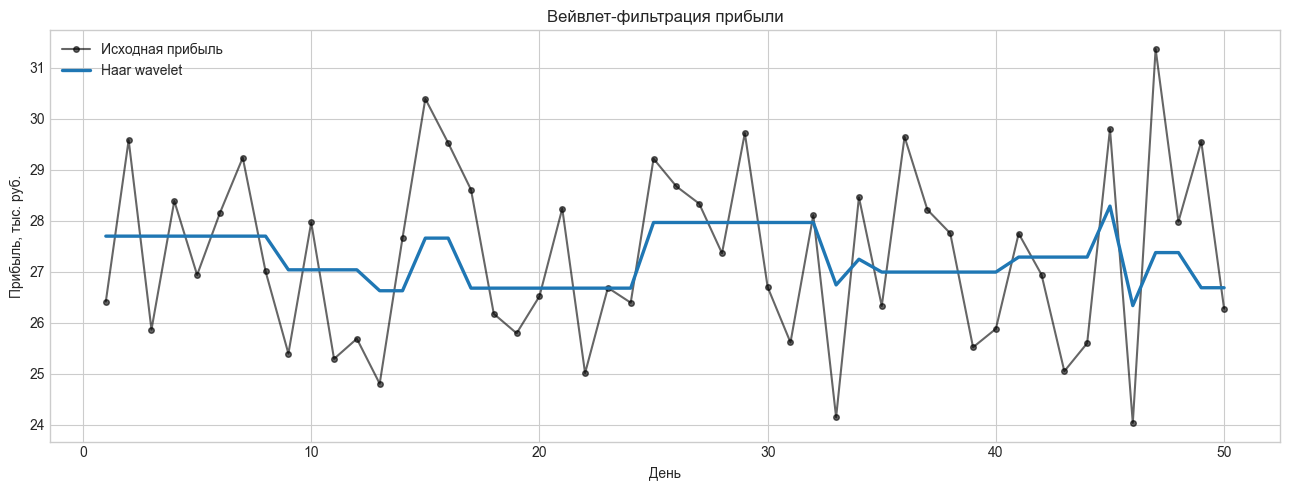

In [11]:
fig, axis = plt.subplots(figsize=(13, 5))
axis.plot(sales_data["day"], sales_data["profit"], color="black", alpha=0.6, marker="o", markersize=4, label="Исходная прибыль")
axis.plot(sales_data["day"], wavelet_profit, linewidth=2.4, label="Haar wavelet")
axis.set_title("Вейвлет-фильтрация прибыли")
axis.set_xlabel("День")
axis.set_ylabel("Прибыль, тыс. руб.")
axis.legend()
fig.tight_layout()
plt.show()

## Загрузка Kaggle-датасета

Код ниже скачивает датасет в папку `data/hard`. Эта папка добавлена в `.gitignore`, потому что внешние данные не нужно хранить в репозитории.

In [12]:
sensor_data = None

try:
    dataset_dir = ensure_fitness_tracker_dataset(ROOT / "data" / "hard")
    sensor_data = load_fitness_tracker_data(dataset_dir, max_rows=5000)
    print(f"Dataset: {KAGGLE_DATASET}")
    print(f"Rows loaded: {len(sensor_data)}")
except RuntimeError as error:
    print("Не удалось скачать Kaggle-датасет автоматически.")
    print("Проверь Kaggle API token или скачай датасет вручную в data/hard/fitness_tracker.")
    print(error)

sensor_data.head() if sensor_data is not None else None

Dataset: krishujeniya/fitness-tracker-accelerometer-and-gyroscope-data
Rows loaded: 5000


,timestamp,accelerometer_x,accelerometer_y,accelerometer_z,gyroscope_x,gyroscope_y,gyroscope_z,sample_index,acceleration_magnitude,gyroscope_magnitude
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,0,0.979669,3.225625
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,1,0.973752,2.887270
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,2,0.973795,2.936720
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,3,0.960118,9.473502
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,4,0.964953,4.623585


## Фильтрация двух датчиков

Для сравнения двух датчиков строятся модули векторов ускорения и угловой скорости:

$$
|a| = \sqrt{a_x^2+a_y^2+a_z^2}, \qquad |g| = \sqrt{g_x^2+g_y^2+g_z^2}.
$$

Затем оба ряда фильтруются одинаковым Haar wavelet-фильтром.

In [13]:
if sensor_data is not None:
    sensor_sample = sensor_data.iloc[:1000].copy()
    sensor_sample["acceleration_wavelet"] = haar_wavelet_denoise(sensor_sample["acceleration_magnitude"], levels=5)
    sensor_sample["gyroscope_wavelet"] = haar_wavelet_denoise(sensor_sample["gyroscope_magnitude"], levels=5)
else:
    sensor_sample = None

sensor_sample.head() if sensor_sample is not None else None

,timestamp,accelerometer_x,accelerometer_y,accelerometer_z,gyroscope_x,gyroscope_y,gyroscope_z,sample_index,acceleration_magnitude,gyroscope_magnitude,acceleration_wavelet,gyroscope_wavelet
0,2019-01-11 15:08:05.200,0.013500,0.977000,-0.071000,-1.8904,2.4392,0.9388,0,0.979669,3.225625,0.985919,16.631587
1,2019-01-11 15:08:05.400,-0.001500,0.970500,-0.079500,-1.6826,-0.8904,2.1708,1,0.973752,2.887270,0.985919,16.631587
2,2019-01-11 15:08:05.600,0.001333,0.971667,-0.064333,2.5608,-0.2560,-1.4146,2,0.973795,2.936720,0.985919,16.631587
3,2019-01-11 15:08:05.800,-0.024000,0.957000,-0.073500,8.0610,-4.5244,-2.0730,3,0.960118,9.473502,0.985919,16.631587
4,2019-01-11 15:08:06.000,-0.028000,0.957667,-0.115000,2.4390,-1.5486,-3.6098,4,0.964953,4.623585,0.985919,16.631587


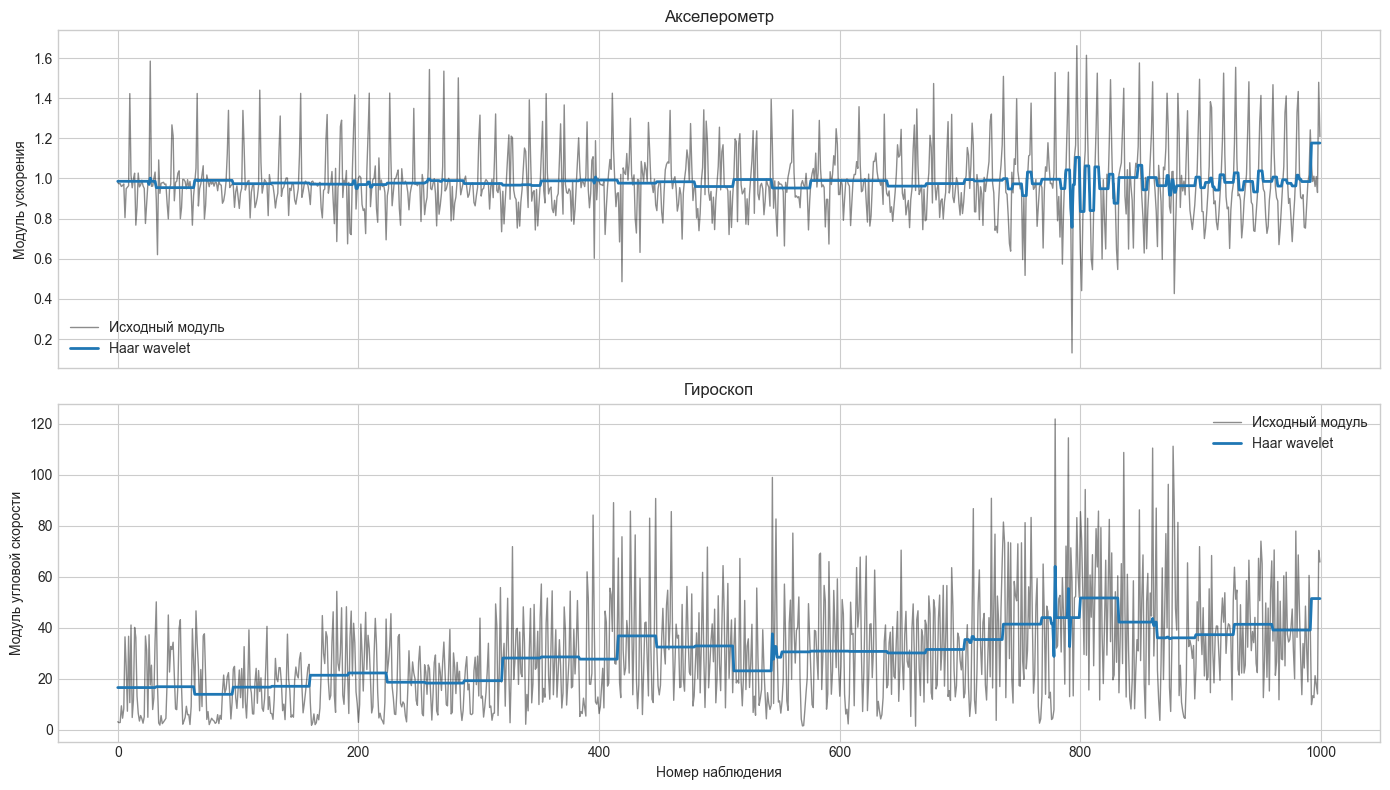

In [14]:
if sensor_sample is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(sensor_sample["sample_index"], sensor_sample["acceleration_magnitude"], color="black", alpha=0.45, linewidth=1, label="Исходный модуль")
    axes[0].plot(sensor_sample["sample_index"], sensor_sample["acceleration_wavelet"], linewidth=2, label="Haar wavelet")
    axes[0].set_title("Акселерометр")
    axes[0].set_ylabel("Модуль ускорения")
    axes[0].legend()

    axes[1].plot(sensor_sample["sample_index"], sensor_sample["gyroscope_magnitude"], color="black", alpha=0.45, linewidth=1, label="Исходный модуль")
    axes[1].plot(sensor_sample["sample_index"], sensor_sample["gyroscope_wavelet"], linewidth=2, label="Haar wavelet")
    axes[1].set_title("Гироскоп")
    axes[1].set_xlabel("Номер наблюдения")
    axes[1].set_ylabel("Модуль угловой скорости")
    axes[1].legend()

    fig.tight_layout()
    plt.show()

In [15]:
if sensor_sample is not None:
    sensor_summary = pd.concat(
        [
            filtering_summary(sensor_sample["acceleration_magnitude"], {"haar_wavelet": sensor_sample["acceleration_wavelet"]}).assign(sensor="accelerometer"),
            filtering_summary(sensor_sample["gyroscope_magnitude"], {"haar_wavelet": sensor_sample["gyroscope_wavelet"]}).assign(sensor="gyroscope"),
        ],
        ignore_index=True,
    )
    sensor_summary = sensor_summary[["sensor", "method", "rmse_to_original", "smoothness", "smoothness_ratio"]]
else:
    sensor_summary = None

sensor_summary

,sensor,method,rmse_to_original,smoothness,smoothness_ratio
0,accelerometer,haar_wavelet,0.163613,0.023919,0.121280
1,gyroscope,haar_wavelet,18.545222,1.930844,0.075224


In [16]:
if sensor_sample is not None:
    sensor_corr = sensor_sample[[
        "acceleration_magnitude",
        "gyroscope_magnitude",
        "acceleration_wavelet",
        "gyroscope_wavelet",
    ]].corr()
else:
    sensor_corr = None

sensor_corr

,acceleration_magnitude,gyroscope_magnitude,acceleration_wavelet,gyroscope_wavelet
acceleration_magnitude,1.000000,0.169580,0.365068,0.021167
gyroscope_magnitude,0.169580,1.000000,0.056459,0.465886
acceleration_wavelet,0.365068,0.056459,1.000000,0.104972
gyroscope_wavelet,0.021167,0.465886,0.104972,1.000000


## Выводы

На ряде прибыли Haar wavelet-фильтр заметно сжимает диапазон колебаний: исходная прибыль меняется примерно от 24.04 до 31.37 тыс. руб., а после фильтрации значения лежат примерно в диапазоне от 26.34 до 28.29 тыс. руб. Средний уровень при этом почти сохраняется: около 27.3 тыс. руб. Это означает, что фильтр хорошо выделяет общий уровень прибыли, но агрессивно подавляет отдельные дневные пики и провалы.

На графике акселерометра исходный сигнал большую часть времени держится около 1.0 по модулю, но содержит короткие выбросы до 1.66. После фильтрации линия становится почти ровной: стандартное отклонение уменьшается примерно с 0.173 до 0.032, а `smoothness_ratio` равен примерно 0.121. Это показывает, что для ускорения вейвлет в основном убирает одиночные резкие скачки и оставляет базовый уровень движения.

На графике гироскопа движение выражено сильнее: исходный модуль угловой скорости имеет большие пики, максимум около 121.93. После фильтрации максимум снижается примерно до 64.16, но участок активного движения сохраняется. Особенно заметная активность приходится примерно на наблюдения 780-930: там одновременно видны пики гироскопа и повышенные значения акселерометра. Значит, этот фрагмент, вероятно, соответствует наиболее интенсивной части упражнения.

По таблице `sensor_summary` гироскоп сглаживается сильнее акселерометра: `smoothness_ratio` около 0.075 против 0.121. Это логично, потому что гироскопический сигнал в выбранном фрагменте намного более резкий и шумный. Корреляция между исходными модулями акселерометра и гироскопа невысокая, около 0.17, поэтому датчики не дублируют друг друга: акселерометр отражает линейное ускорение, а гироскоп — вращательные движения.